In [149]:
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, resolution=0.02):

    # setup marker generator and color map
    markers = ('s', '*', 'o', '^', 'v', '*')
    colors = ('red', 'blue', 'lightgreen', 'gray', 'cyan')
    cmap = ListedColormap(colors[:len(np.unique(y))])

    # plot the decision surface
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))
    Z = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    Z = Z.reshape(xx1.shape)
    plt.contourf(xx1, xx2, Z, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    # plot class examples
    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='black')

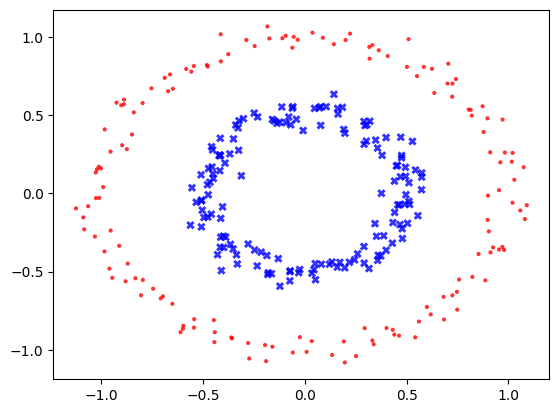

In [150]:
from sklearn.datasets import make_moons, make_circles

X, y = make_circles(
    n_samples=300,
    factor=0.5,   # raggio del cerchio interno
    noise=0.05,
    random_state=1
)
markers=['.', 'X']
colors = ['r', 'b']

for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0], 
                    y=X[y == cl, 1],
                    alpha=0.8, 
                    c=colors[idx],
                    marker=markers[idx], 
                    label=cl, 
                    edgecolor='none')

In [151]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

In [152]:
from sklearn.svm import SVC

linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)
print("Accuracy SVM lineare:", np.mean(y_test == y_pred_linear))

Accuracy SVM lineare: 0.4444444444444444


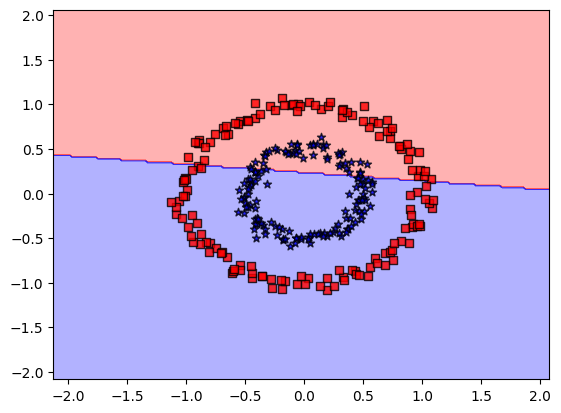

In [153]:
plot_decision_regions(X, y, linear_svm)

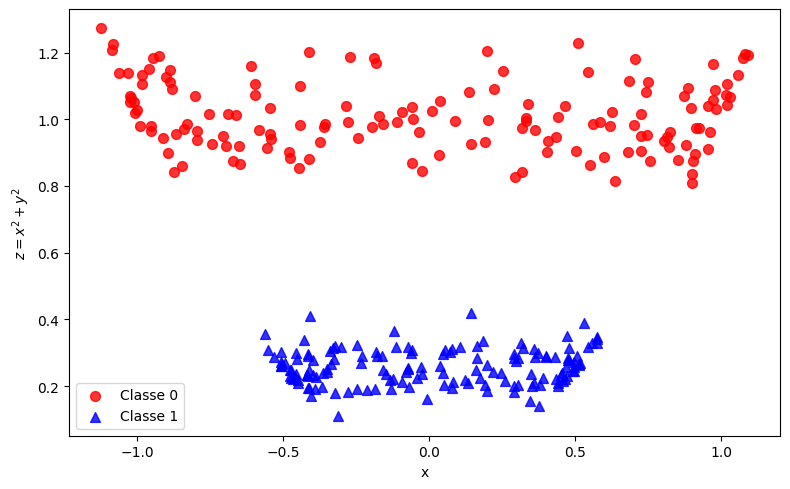

In [155]:
x1 = X[:, 0]
x2 = X[:, 1]

z = x1**2+x2**2

X_3d = np.c_[x1, x2, z]

markers = ['o', '^']
colors = ['red', 'blue']

# Plot 3D
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

for idx, cl in enumerate(np.unique(y)):
    ax.scatter(
        X_3d[y == cl, 0],
        X_3d[y == cl, 2],
        c=colors[idx],
        marker=markers[idx],
        s=50,
        alpha=0.8,
        label=f'Classe {cl}'
    )

# Etichette
ax.set_xlabel('x')

ax.set_ylabel(r'$z = x^2 + y^2$')

# Angolo di visualizzazione

ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_3d, y, test_size=0.3, random_state=1
)

In [ ]:
linear_svm = SVC(kernel='linear')
linear_svm.fit(X_train, y_train)

y_pred_linear = linear_svm.predict(X_test)
print("Accuracy SVM lineare:", np.mean(y_test == y_pred_linear))

Accuracy SVM lineare: 1.0


Le trasformazioni in spazi ad alta dimensionalità consentono di rendere i dati più facilmente separabili, migliorando così le prestazioni dei modelli di classificazione. Tuttavia, lavorare esplicitamente in questi spazi può essere molto costoso dal punto di vista computazionale, soprattutto quando il numero di feature è elevato o quando si considerano trasformazioni polinomiali di grado alto.

Il *kernel trick* risolve questo problema evitando di calcolare esplicitamente la trasformazione $\phi(x)$, che mappa i dati dallo spazio originale a uno spazio di dimensione più alta $\mathcal{H}$.

Una funzione kernel $K$ permette infatti di calcolare direttamente il prodotto scalare tra le immagini di due vettori nello spazio trasformato:

$$
K(x_1, x_2) = \phi(x_1) \cdot \phi(x_2)
$$

Il principio alla base del kernel trick è che molti algoritmi di machine learning, come le Support Vector Machines (SVM), possono essere formulati utilizzando esclusivamente prodotti scalari tra vettori. Di conseguenza, invece di calcolare direttamente il prodotto scalare $\phi(x_1) \cdot \phi(x_2)$, è possibile sostituirlo con $K(x_1, x_2)$, ottenendo il corrispondente prodotto scalare nello spazio $\mathcal{H}$.

In questo modo si sfruttano i vantaggi delle trasformazioni in spazi ad alta dimensionalità senza dover eseguire esplicitamente i calcoli in tali spazi, con un notevole risparmio computazionale.

Un kernel molto diffuso è il kernel gaussiano o Radial Basis Function (RBF), definito come

$$
K(x_1, x_2) =e^{\left(-\gamma \|x_1 - x_2\|^2\right)}
$$

dove $\gamma > 0$ controlla l'influenza dei singoli punti di addestramento. Questa funzione può essere espansa tramite lo sviluppo in serie dell’esponenziale:

$$
e^t = \sum_{n=0}^{\infty} \frac{t^n}{n!}
$$

Applicandolo al kernel, si ottiene una combinazione infinita di termini polinomiali. Overo, i dati vengono proiettati in uno spazio di dimensione potenzialmente infinita. Questo è particolarmente efficace quando la relazione tra le variabili è complessa e non lineare.

In [175]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1
)

rbf_svm = SVC(kernel='rbf', gamma=100)
rbf_svm.fit(X_train, y_train)

y_pred_rbf = rbf_svm.predict(X_test)
print("Accuracy SVM RBF:", np.mean(y_test == y_pred_rbf))

Accuracy SVM RBF: 1.0


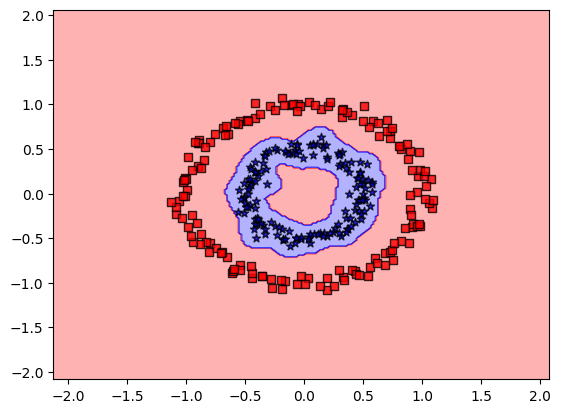

In [176]:
plot_decision_regions(X, y, rbf_svm)

# Valutare un modello


![bias](18_01.png)


Un elevato `bias` indica un errore sistematico dovuto alla semplicità del modello, non legato al caso. L'elevata `varianza` indica overfitting, un modello troppo complesso per i dati disponibili: più addestramenti (su training set diversi) portano a diversi modelli con prestazioni diverse.

Con la regolarizzazione, ad esempio la *L2* ($\gamma||w||^2/2$), si penalizzano valori estremi e si riduce la varianza.

In [ ]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [177]:
# ==========================================================
# 1. Dataset sintetico con un po' di rumore
# ==========================================================
X, y = make_classification(
    n_samples=300, # 1000
    n_features=20,
    n_informative=5,
    n_redundant=2,
    n_classes=2,
    flip_y=0.10,       # 10% di rumore
    class_sep=0.8,
    random_state=1
)

In [ ]:

accuracies = []
# ==========================================================
# Proviamo diversi random_state
# ==========================================================
for seed in range(10):

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.15,
        stratify=y,
        random_state=seed
    )

    # Modello SVM
    model = SVC(
        kernel='rbf',
        C = 0.5, # 1
        gamma = 0.1 # 0.5
    )

    # Training
    model.fit(X_train, y_train)

    # Test accuracy
    y_test_pred = model.predict(X_test)
    test_acc = np.mean(y_test==y_test_pred)

    accuracies.append(test_acc)
    print( f"Test Accuracy = {test_acc:.4f}")

print(f"Accuracies variance = {np.var(np.array(accuracies))}")


Test Accuracy = 0.7333
Test Accuracy = 0.8222
Test Accuracy = 0.8222
Test Accuracy = 0.7333
Test Accuracy = 0.7556
Test Accuracy = 0.8222
Test Accuracy = 0.8222
Test Accuracy = 0.8222
Test Accuracy = 0.7333
Test Accuracy = 0.7111
Accuracies variance = 0.0020740740740740732


### Metodo holdout

Si usano training set e validation set per scegliere gli iperparametri, infine il test set per la verifica finale. 

In [179]:
# ==========================================================
# Dataset sintetico con un po' di rumore
# ==========================================================
X, y = make_classification(
    n_samples=1500,
    n_features=20,
    n_informative=8,
    n_redundant=4,
    n_classes=2,
    flip_y=0.05,       # 5% di etichette errate
    class_sep=1.0,
    random_state=1
)


In [180]:
# Test set = 15%
X_temp, X_test, y_temp, y_test = train_test_split(
    X,
    y,
    test_size=0.15,
    stratify=y,
    random_state=0
)

# Validation set = 15% del totale
# X_temp = 85% del totale -> 15/85 = 0.17647
X_train, X_val, y_train, y_val = train_test_split(
    X_temp,
    y_temp,
    test_size=0.17647,
    stratify=y_temp,
    random_state=0
)

print("Training set   :", len(X_train))
print("Validation set :", len(X_val))
print("Test set       :", len(X_test))

Training set   : 1050
Validation set : 225
Test set       : 225


In [181]:
# ==========================================================
# MODELLO 1
# ==========================================================
model1 = SVC(
    kernel='rbf',
    C=1,
    gamma=1.5,
    random_state=1
)

model1.fit(X_train, y_train)

# Accuracy sul training set
train_pred_1 = model1.predict(X_train)
train_acc_1 = np.mean(y_train == train_pred_1)

# Accuracy sul validation set
val_pred_1 = model1.predict(X_val)
val_acc_1 =  np.mean(y_val == val_pred_1)

print("\nMODELLO 1 (alta varianza)")
print(f"Training accuracy   : {train_acc_1:.4f}")
print(f"Validation accuracy : {val_acc_1:.4f}")


MODELLO 1 (alta varianza)
Training accuracy   : 1.0000
Validation accuracy : 0.5022


In [182]:
# ==========================================================
# MODELLO 2
# ==========================================================
model2 = SVC(
    kernel='rbf',
    C=0.5,
    gamma=0.01,
    random_state=1
)

model2.fit(X_train, y_train)

# Accuracy sul training set
train_pred_2 = model2.predict(X_train)
train_acc_2 = np.mean(y_train==train_pred_2)

# Accuracy sul validation set
val_pred_2 = model2.predict(X_val)
val_acc_2 = np.mean(y_val==val_pred_2)

print("\nMODELLO 2 (varianza ridotta)")
print(f"Training accuracy   : {train_acc_2:.4f}")
print(f"Validation accuracy : {val_acc_2:.4f}")



MODELLO 2 (varianza ridotta)
Training accuracy   : 0.9114
Validation accuracy : 0.9067


In [183]:
# ==========================================================
# Scelta del modello migliore
# ==========================================================
if val_acc_2 > val_acc_1:
    best_model = model2
    print("\nIl Modello 2 è migliore sul validation set.")
else:
    best_model = model1
    print("\nIl Modello 1 è migliore sul validation set.")



Il Modello 2 è migliore sul validation set.


In [184]:
# ==========================================================
# Riaddestramento finale su Train + Validation
# ==========================================================
X_train_final = np.vstack([X_train, X_val])
y_train_final = np.hstack([y_train, y_val])

best_model.fit(X_train_final, y_train_final)

# ==========================================================
# Valutazione finale sul Test Set
# ==========================================================
y_test_pred = best_model.predict(X_test)
test_acc = np.mean(y_test==y_test_pred)

print(f"\nAccuracy finale sul Test Set: {test_acc:.4f}")


Accuracy finale sul Test Set: 0.8800


## Convalida incrociata (cross validation)

Il dataset è diviso in più parti (fold), e addestrato più volte usando i fold come validazione.

In [185]:
from sklearn.model_selection import StratifiedKFold

kf = StratifiedKFold(n_splits=4, shuffle=True, random_state=1)

X = range(12)
y = [0,1,1,1,0,1,1,1,0,0,1,0]

for train_idx, val_idx in kf.split(X, y):
    print(train_idx, val_idx)

[ 0  1  2  3  5  7  8 10 11] [4 6 9]
[ 2  3  4  5  6  7  8  9 11] [ 0  1 10]
[ 0  1  2  3  4  6  8  9 10] [ 5  7 11]
[ 0  1  4  5  6  7  9 10 11] [2 3 8]


Il dataset è diviso in 4 part, ad ogni iterazione viene utilizzata una delle parti per la validazione, il resto per il training

In [186]:
# ==========================================================
# 1. Dataset sintetico
# ==========================================================
X, y = make_classification(
    n_samples=1000,
    n_features=20,
    n_informative=6,
    n_redundant=4,
    n_classes=2,
    flip_y=0.08,
    class_sep=0.9,
    random_state=1
)

In [187]:
# ==========================================================
# K-Fold Cross Validation
# ==========================================================
kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)


In [188]:
# ==========================================================
# HOLD OUT DEL TEST SET (mai toccato)
# ==========================================================
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.15,
    stratify=y,
    random_state=1
)

In [196]:
# ==========================================================
# Iperparametri da testare
# ==========================================================
C_values = [0.1, 1, 10, 12, 15, 17]
gamma_values = [#0.001,
    0.01,
    #0.1
    ]

best_score = 0
best_params = None

In [197]:
# ==========================================================
# Loop sugli iperparametri
# ==========================================================
for C in C_values:
    for gamma in gamma_values:

        fold_scores = []

        # ======================================================
        # Cross-validation
        # ======================================================
        for train_idx, val_idx in kf.split(X_train_full, y_train_full):

            X_train, X_val = X_train_full[train_idx], X_train_full[val_idx]
            y_train, y_val = y_train_full[train_idx], y_train_full[val_idx]

            model = SVC(kernel="rbf", C=C, gamma=gamma)

            model.fit(X_train, y_train)
            preds = model.predict(X_val)

            acc = np.mean(y_val==preds)
            fold_scores.append(acc)

        mean_score = np.mean(fold_scores)

        print(f"C={C:<3} gamma={gamma:<5} -> CV accuracy = {mean_score:.4f}")

        if mean_score > best_score:
            best_score = mean_score
            best_params = (C, gamma)


C=0.1 gamma=0.01  -> CV accuracy = 0.8424
C=1   gamma=0.01  -> CV accuracy = 0.8682
C=10  gamma=0.01  -> CV accuracy = 0.8729
C=12  gamma=0.01  -> CV accuracy = 0.8729
C=15  gamma=0.01  -> CV accuracy = 0.8671
C=17  gamma=0.01  -> CV accuracy = 0.8659


In [190]:

# ==========================================================
# Migliori iperparametri
# ==========================================================
print("\nMigliori iperparametri trovati:")
print("C =", best_params[0], "gamma =", best_params[1])
print("CV accuracy media =", best_score)



Migliori iperparametri trovati:
C = 10 gamma = 0.01
CV accuracy media = 0.8729411764705881


In [ ]:
# ==========================================================
# Modello finale su tutto il dataset
# ==========================================================
final_model = SVC(
    kernel="rbf",
    C=best_params[0],
    gamma=best_params[1]
)

final_model.fit(X_train_full, y_train_full)

print("\nModello finale addestrato su tutto il dataset.")


Modello finale addestrato su tutto il dataset.


In [ ]:
# ==========================================================
# TEST FINALE (mai usato prima)
# ==========================================================
test_pred = final_model.predict(X_test)
test_acc = np.mean(y_test==test_pred)

print("\nMigliori parametri:", best_params)
print("Test accuracy finale:", test_acc)


Migliori parametri: (10, 0.01)
Test accuracy finale: 0.8466666666666667


## Matrice di confusione

In [198]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred)

print("Matrice di confusione:")
print(cm)

Matrice di confusione:
[[65  7]
 [16 62]]


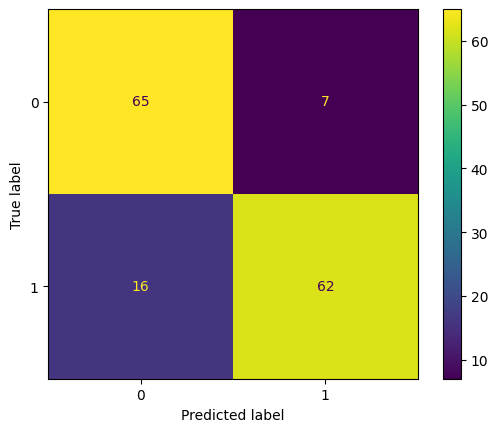

In [199]:
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [200]:
tn, fp, fn, tp = confusion_matrix(y_test, test_pred).ravel()

print(tn, fp, fn, tp)

65 7 16 62


In [201]:
precision = tp / (tp + fp) # frazione di positivi trovati  tra tutti i predetti positivi
recall = tp / (tp + fn) # frazione di positivi trovati tra tutti i positivi reali

print("\nPrecision:", precision)
print("Recall:", recall)


Precision: 0.8985507246376812
Recall: 0.7948717948717948
